##   Install Libraries

In [2]:
!pip install transformers datasets torchvision pillow -q

import os
import pandas as pd
import torch
import torch.nn as nn
import requests
from PIL import Image
from io import BytesIO
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, BertModel
from torchvision.models import resnet50


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
W0506 15:22:31.085000 18964 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


## Load and Clean Dataset

In [3]:
df = pd.read_csv(r'C:\Users\user\OneDrive - Helwan National University\Desktop\NN\tmdb_text_image_only.csv')
df = df[['overview_enhanced','poster_path','label']]
df = df.dropna().drop_duplicates()

le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

## Image Transform + Local Loader

In [4]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def load_image(poster_path):
    try:
        img = Image.open('images/' + poster_path.replace('/', '')).convert('RGB')
        return image_transform(img)
    except:
        return torch.zeros(3,224,224)

## Tokenizer (BERT)

In [5]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize(text):
    return tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

##  Custom Multimodal Dataset

In [6]:
class TMDBDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        tokens = tokenize(row['overview_enhanced'])
        image = load_image(row['poster_path'])

        return {
            'input_ids': tokens['input_ids'].squeeze(),
            'attention_mask': tokens['attention_mask'].squeeze(),
            'image': image,
            'label': torch.tensor(row['label'])
        }

##  Split + DataLoader

In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

train_loader = DataLoader(TMDBDataset(train_df), batch_size=8, shuffle=True)
test_loader = DataLoader(TMDBDataset(test_df), batch_size=8)

##  CNN + BERT Multimodal Model

In [8]:
class MultimodalModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.cnn = resnet50(pretrained=True)
        self.cnn.fc = nn.Linear(self.cnn.fc.in_features, 512)

        self.fc1 = nn.Linear(512 + 768, 256)
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, input_ids, attention_mask, image):
        text_feat = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).pooler_output

        img_feat = self.cnn(image)

        combined = torch.cat((text_feat, img_feat), dim=1)
        x = self.dropout(self.fc1(combined))
        return self.fc2(x)

##  Training Setup

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = MultimodalModel(num_classes=df['label'].nunique()).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

##  Training Loop
Recording Training Loss and Accuracy

In [ ]:
train_losses = []
train_accuracies = []
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for batch in train_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        img = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(ids, mask, img)
        loss = loss_fn(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch {epoch+1}: Loss={epoch_loss:.4f} | Acc={epoch_acc:.4f}")

Epoch 1: Loss=0.1749 | Acc=0.9457
Epoch 2: Loss=0.0422 | Acc=0.9849
Epoch 3: Loss=0.0153 | Acc=0.9957


## Model Evaluation on Test Set


In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        img = batch['image'].to(device)
        labels = batch['label'].to(device)

        outputs = model(ids, mask, img)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Test Accuracy :", acc)
print("Precision     :", prec)
print("Recall        :", rec)
print("F1 Score      :", f1)

print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))

Test Accuracy : 0.9649446494464945
Precision     : 0.9663745935021871
Recall        : 0.9649446494464945
F1 Score      : 0.9651682414992188

Classification Report:

              precision    recall  f1-score   support

      Action       1.00      0.95      0.97       425
      Comedy       0.92      0.98      0.95       375
      Horror       0.99      0.96      0.98       441
     Romance       0.96      0.98      0.97       385

    accuracy                           0.96      1626
   macro avg       0.96      0.97      0.96      1626
weighted avg       0.97      0.96      0.97      1626



## Training Curves (Loss & Accuracy)

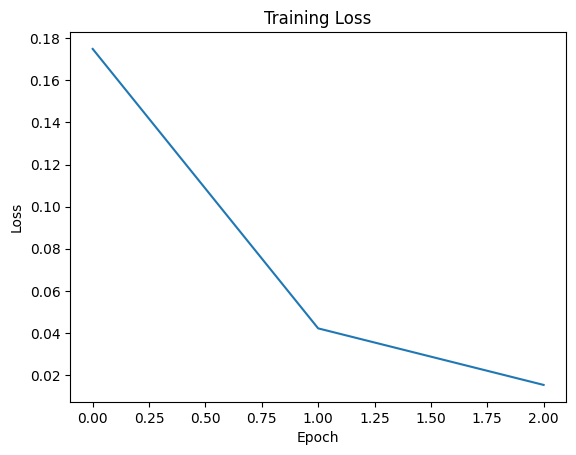

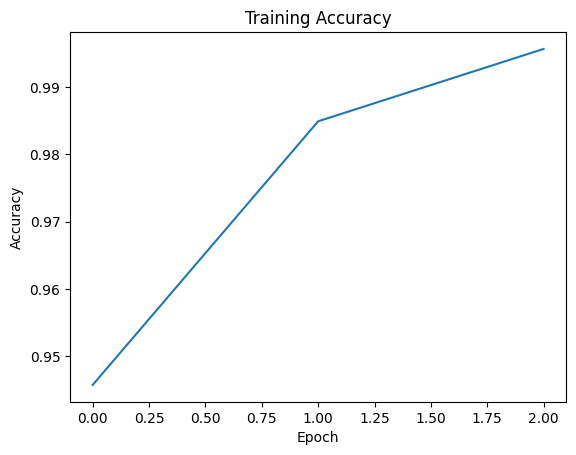

In [ ]:
plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(train_accuracies)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

##  Confusion Matrix Visualization


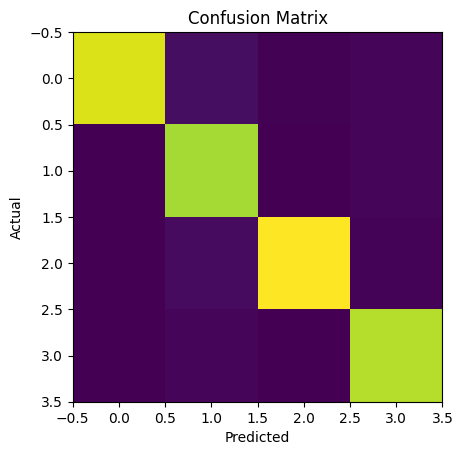

In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()